# LCG 3DEP topographic profile

This notebook turns an ordered WGS 84 point table into a topographic profile by calling the deployed LCG elevation service. It demonstrates the client pattern that can later be used by ArcGIS Pro and the public web interface.

The workflow keeps point identity and order explicit, calculates distance on the WGS 84 ellipsoid, exposes `no_data` results, and writes reviewable CSV, GeoJSON, PNG, and metadata outputs. The returned elevations sample an approximately 10-meter bare-earth DEM and are not survey-grade values.

## 1. Environment setup

Before opening the notebook, activate the project Python 3.12 virtual environment and install the notebook dependency group from the repository root:

```powershell
python -m pip install -e ".[notebooks]"
python -m jupyter lab
```

Select that same virtual environment as the notebook kernel.

In [14]:
from __future__ import annotations

import json
import math
import re
import time
from io import StringIO
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
import requests
from IPython.display import display
from pyproj import Geod
from shapely.geometry import LineString

SERVICE_BASE_URL = "https://elevation.logiccloudgeo.com"
ELEVATION_UNITS = "feet"       # "feet" or "meters"
HORIZONTAL_UNITS = "miles"     # "miles" or "kilometers"
BATCH_SIZE = 250                  # API maximum is 500
REQUEST_TIMEOUT_SECONDS = 90
PAUSE_BETWEEN_BATCHES_SECONDS = 0.5
INPUT_MODE = "file"              # "file" or "pasted_text"
DEFAULT_PROFILE_ID = "profile-1"
COORDINATE_ALIAS_TOLERANCE_DEGREES = 1e-5
PASTED_TABLE = """XCoord\tYCoord\tORIG_SEQ\tORIG_FID
-84.4200\t30.2800\t1\t1
-84.3925\t30.3075\t2\t1
"""

if ELEVATION_UNITS not in {"feet", "meters"}:
    raise ValueError("ELEVATION_UNITS must be 'feet' or 'meters'.")
if HORIZONTAL_UNITS not in {"miles", "kilometers"}:
    raise ValueError("HORIZONTAL_UNITS must be 'miles' or 'kilometers'.")
if not 1 <= BATCH_SIZE <= 500:
    raise ValueError("BATCH_SIZE must be between 1 and 500.")
if INPUT_MODE not in {"file", "pasted_text"}:
    raise ValueError("INPUT_MODE must be 'file' or 'pasted_text'.")

## 2. Locate the input and output directories

Jupyter kernels can start in either the repository root or the `notebooks` directory. This cell searches upward for the project markers instead of assuming one current working directory. The default tab-delimited file demonstrates the ArcGIS `XCoord`, `YCoord`, `ORIG_SEQ`, and `ORIG_FID` field names.

In [15]:
def find_repository_root(start: Path) -> Path:
    candidates = (start.resolve(), *start.resolve().parents)
    for candidate in candidates:
        if (candidate / "pyproject.toml").is_file() and (candidate / "sample_data").is_dir():
            return candidate
    raise FileNotFoundError(
        "Repository root not found. Start JupyterLab from this project's repository."
    )


REPOSITORY_ROOT = find_repository_root(Path.cwd())
INPUT_PATH = REPOSITORY_ROOT / "sample_data" / "florida_profile_points_100m.tsv"
OUTPUT_DIRECTORY = REPOSITORY_ROOT / "output"

print(f"Repository: {REPOSITORY_ROOT}")
print(f"Input:      {INPUT_PATH}")
print(f"Output:     {OUTPUT_DIRECTORY}")

Repository: C:\Users\leste\OneDrive - LogicCloud Geo\Documents\Data\Python_Elevation_Service_UsingHyRiver\usgs-elevation-service
Input:      C:\Users\leste\OneDrive - LogicCloud Geo\Documents\Data\Python_Elevation_Service_UsingHyRiver\usgs-elevation-service\sample_data\florida_profile_points_100m.tsv
Output:     C:\Users\leste\OneDrive - LogicCloud Geo\Documents\Data\Python_Elevation_Service_UsingHyRiver\usgs-elevation-service\output


## 3. Check application health

The health route verifies DNS, TLS, App Service routing, the container, and FastAPI without consuming an upstream elevation query. A successful health check does not guarantee that the upstream elevation provider is available, but it separates application availability from provider availability.

In [16]:
health_url = f"{SERVICE_BASE_URL.rstrip('/')}/health"
health_response = requests.get(health_url, timeout=15)
health_response.raise_for_status()
health = health_response.json()
display(pd.Series(health, name="value").to_frame())

,value
status,ok
service,USGS Elevation Service
version,0.1.0
provider,py3dep


## 4. Read the ordered point table

A profile needs at least two points, a numeric sequence, and one recognized coordinate pair: `latitude`/`longitude` or ArcGIS `YCoord`/`XCoord`. `ORIG_SEQ` is accepted as the sequence field, and `ORIG_FID` or `profile_id` can identify the overall line. API keys are generated internally, so `db_key` and `label` are not required. CSV, TSV, and pasted tabular text are supported.

The included Florida profile is synthetic test data, not a surveyed alignment.

In [17]:
def read_profile_table(mode: str, path: Path, pasted_text: str) -> pd.DataFrame:
    if mode == "pasted_text":
        if not pasted_text.strip():
            raise ValueError("PASTED_TABLE is blank. Paste a CSV or tab-delimited table.")
        return pd.read_csv(StringIO(pasted_text.strip()), sep=None, engine="python")

    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix in {".tsv", ".tab", ".txt"}:
        return pd.read_csv(path, sep="\t")
    return pd.read_csv(path, sep=None, engine="python")


raw_points = read_profile_table(INPUT_MODE, INPUT_PATH, PASTED_TABLE)
print(f"Read {len(raw_points):,} input points.")
display(raw_points.head(10))

Read 486 input points.


,XCoord,YCoord,ORIG_FID,ORIG_SEQ
0,-84.420000,30.280000,1,1
1,-84.419319,30.280681,1,2
2,-84.418637,30.281363,1,3
3,-84.417956,30.282044,1,4
4,-84.417275,30.282725,1,5
5,-84.416594,30.283406,1,6
6,-84.415912,30.284088,1,7
7,-84.415231,30.284769,1,8
8,-84.414550,30.285450,1,9
9,-84.413869,30.286131,1,10


## 5. Validate locally before using the API

Client validation provides immediate row-specific feedback and avoids consuming network or provider capacity for a malformed request. The service independently validates every public request because it cannot trust clients to perform this step.

In [18]:
DB_KEY_PATTERN = re.compile(r"^[A-Za-z0-9][A-Za-z0-9_.-]{0,63}$")


def normalize_columns(input_frame: pd.DataFrame) -> pd.DataFrame:
    frame = input_frame.copy()
    normalized = [str(column).strip().lower() for column in frame.columns]
    if len(normalized) != len(set(normalized)):
        raise ValueError("Column names are duplicated after case normalization.")
    frame.columns = normalized
    return frame


def add_coordinate_alias(
    frame: pd.DataFrame,
    canonical: str,
    alias: str,
) -> None:
    if canonical not in frame.columns and alias not in frame.columns:
        return
    if canonical not in frame.columns:
        frame[canonical] = frame[alias]
        return
    if alias not in frame.columns:
        return

    canonical_values = pd.to_numeric(frame[canonical], errors="coerce")
    alias_values = pd.to_numeric(frame[alias], errors="coerce")
    comparable = canonical_values.notna() & alias_values.notna()
    mismatch = (canonical_values - alias_values).abs().gt(
        COORDINATE_ALIAS_TOLERANCE_DEGREES
    ) & comparable
    if mismatch.any():
        rows = list(frame.index[mismatch])
        raise ValueError(
            f"{canonical} and {alias} disagree beyond the tolerance at rows {rows}."
        )


def api_profile_slug(value: object) -> str:
    text = str(value).strip()
    slug = re.sub(r"[^A-Za-z0-9_.-]+", "-", text).strip("-._")
    if not slug:
        slug = DEFAULT_PROFILE_ID
    if not slug[0].isalnum():
        slug = f"profile-{slug}"
    return slug[:48]


def validate_profile_points(input_frame: pd.DataFrame) -> pd.DataFrame:
    if len(input_frame) < 2:
        raise ValueError("A topographic profile requires at least two points.")

    frame = normalize_columns(input_frame)
    add_coordinate_alias(frame, "longitude", "xcoord")
    add_coordinate_alias(frame, "latitude", "ycoord")

    if "sequence" not in frame.columns and "orig_seq" in frame.columns:
        frame["sequence"] = frame["orig_seq"]
    if "profile_id" not in frame.columns:
        if "orig_fid" in frame.columns:
            frame["profile_id"] = "profile-" + frame["orig_fid"].astype(str)
        else:
            frame["profile_id"] = DEFAULT_PROFILE_ID

    required = {"latitude", "longitude", "sequence"}
    missing = required - set(frame.columns)
    if missing:
        raise ValueError(
            f"Missing required profile fields: {sorted(missing)}. "
            "Coordinates may also be supplied as XCoord/YCoord and sequence as ORIG_SEQ."
        )

    for column, lower, upper in (
        ("latitude", -90.0, 90.0),
        ("longitude", -180.0, 180.0),
    ):
        values = pd.to_numeric(frame[column], errors="coerce")
        invalid = values.isna() | ~values.map(math.isfinite) | ~values.between(lower, upper)
        if invalid.any():
            rows = list(frame.index[invalid])
            raise ValueError(f"Invalid {column} values at input rows {rows}")
        frame[column] = values.astype(float)

    sequence = pd.to_numeric(frame["sequence"], errors="coerce")
    invalid_sequence = (
        sequence.isna()
        | ~sequence.map(math.isfinite)
        | sequence.mod(1).ne(0)
        | sequence.lt(1)
    )
    if invalid_sequence.any():
        rows = list(frame.index[invalid_sequence])
        raise ValueError(f"Invalid sequence values at input rows {rows}")
    if sequence.duplicated(keep=False).any():
        duplicates = sequence[sequence.duplicated(keep=False)].tolist()
        raise ValueError(f"Duplicate sequence values: {duplicates}")
    frame["sequence"] = sequence.astype("int64")
    frame = frame.sort_values("sequence", kind="stable").reset_index(drop=True)

    profile_ids = frame["profile_id"].astype("string").str.strip()
    if profile_ids.isna().any() or profile_ids.eq("").any():
        raise ValueError("profile_id contains a blank value.")
    if profile_ids.nunique() != 1:
        raise ValueError("This notebook processes one profile_id per run.")
    frame["profile_id"] = profile_ids

    consecutive_duplicate = frame[["longitude", "latitude"]].eq(
        frame[["longitude", "latitude"]].shift()
    ).all(axis=1)
    if consecutive_duplicate.any():
        rows = list(frame.index[consecutive_duplicate])
        raise ValueError(f"Consecutive profile points repeat coordinates at rows {rows}.")

    slug = api_profile_slug(profile_ids.iloc[0])
    frame["api_db_key"] = frame["sequence"].map(
        lambda value: f"{slug}-{value:06d}"
    )
    if not frame["api_db_key"].map(lambda value: bool(DB_KEY_PATTERN.fullmatch(value))).all():
        raise ValueError("Generated API keys do not satisfy the service identifier rules.")
    return frame


In [19]:
points = validate_profile_points(raw_points)
print(f"Validated {len(points):,} ordered points for {points['profile_id'].iloc[0]}.")
display(points.head(10))
if len(points) > 10:
    print("Last three ordered points:")
    display(points.tail(3))

Validated 486 ordered points for profile-1.


,xcoord,ycoord,orig_fid,orig_seq,longitude,latitude,sequence,profile_id,api_db_key
0,-84.420000,30.280000,1,1,-84.420000,30.280000,1,profile-1,profile-1-000001
1,-84.419319,30.280681,1,2,-84.419319,30.280681,2,profile-1,profile-1-000002
2,-84.418637,30.281363,1,3,-84.418637,30.281363,3,profile-1,profile-1-000003
3,-84.417956,30.282044,1,4,-84.417956,30.282044,4,profile-1,profile-1-000004
4,-84.417275,30.282725,1,5,-84.417275,30.282725,5,profile-1,profile-1-000005
5,-84.416594,30.283406,1,6,-84.416594,30.283406,6,profile-1,profile-1-000006
6,-84.415912,30.284088,1,7,-84.415912,30.284088,7,profile-1,profile-1-000007
7,-84.415231,30.284769,1,8,-84.415231,30.284769,8,profile-1,profile-1-000008
8,-84.414550,30.285450,1,9,-84.414550,30.285450,9,profile-1,profile-1-000009
9,-84.413869,30.286131,1,10,-84.413869,30.286131,10,profile-1,profile-1-000010


Last three ordered points:


,xcoord,ycoord,orig_fid,orig_seq,longitude,latitude,sequence,profile_id,api_db_key
483,-84.090720,30.609280,1,484,-84.090720,30.609280,484,profile-1,profile-1-000484
484,-84.090038,30.609962,1,485,-84.090038,30.609962,485,profile-1,profile-1-000485
485,-84.090000,30.610000,1,486,-84.090000,30.610000,486,profile-1,profile-1-000486


## 6. Diagnose the ordered line before querying elevations

Sequence errors can create long jumps, sharp reversals, or a self-crossing line. This cell calculates plan-view diagnostics before consuming elevation-service capacity. Warnings require visual review but do not automatically reject a legitimately curved alignment.

,value
points,486
segments,485
total_length_km,48.405582
median_segment_m,100.000023
maximum_segment_m,100.001407
maximum_to_median_ratio,1.000014
maximum_turn_degrees,0.000202
sinuosity,1.000001
self_crossing,False


No sequence or self-crossing warnings were detected.


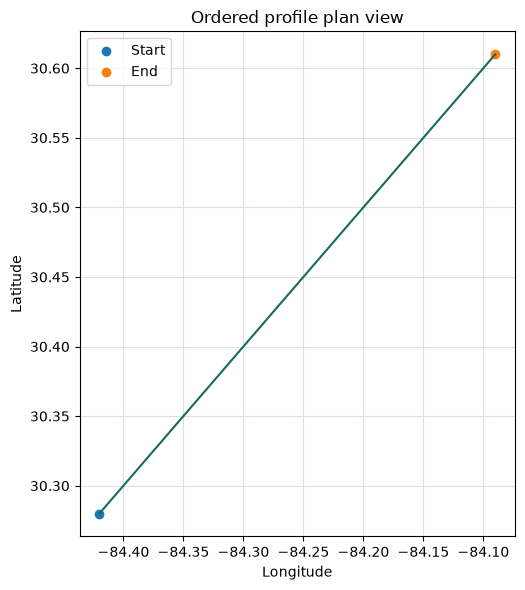

In [20]:
def angle_difference_degrees(first: float, second: float) -> float:
    return abs((second - first + 180.0) % 360.0 - 180.0)


def analyze_profile_geometry(
    ordered_points: pd.DataFrame,
) -> tuple[dict[str, Any], list[str]]:
    geod = Geod(ellps="WGS84")
    coordinates = list(
        zip(ordered_points["longitude"], ordered_points["latitude"], strict=True)
    )
    segment_distances: list[float] = []
    azimuths: list[float] = []

    for previous, current in zip(coordinates[:-1], coordinates[1:], strict=True):
        azimuth, _, distance_m = geod.inv(*previous, *current)
        azimuths.append(float(azimuth))
        segment_distances.append(float(distance_m))

    _, _, endpoint_distance_m = geod.inv(*coordinates[0], *coordinates[-1])
    total_distance_m = sum(segment_distances)
    median_segment_m = float(pd.Series(segment_distances).median())
    maximum_segment_m = max(segment_distances)
    maximum_to_median_ratio = maximum_segment_m / median_segment_m
    turn_angles = [
        angle_difference_degrees(first, second)
        for first, second in zip(azimuths[:-1], azimuths[1:], strict=True)
    ]
    maximum_turn_degrees = max(turn_angles, default=0.0)
    self_crossing = not LineString(coordinates).is_simple
    sinuosity = total_distance_m / endpoint_distance_m if endpoint_distance_m > 0 else None

    messages: list[str] = []
    if self_crossing:
        messages.append("The ordered profile crosses or overlaps itself. Review sequence.")
    if maximum_to_median_ratio > 5.0:
        messages.append(
            "At least one segment is more than five times the median spacing. "
            "Review sequence and missing rows."
        )
    if maximum_turn_degrees >= 135.0:
        messages.append(
            f"A sharp direction change of {maximum_turn_degrees:.1f} degrees was found."
        )
    if sinuosity is None:
        messages.append("The first and last coordinates coincide; confirm an open profile.")
    elif sinuosity > 2.0:
        messages.append(
            f"Profile sinuosity is {sinuosity:.2f}; confirm that the path is intentional."
        )

    metrics = {
        "points": len(ordered_points),
        "segments": len(segment_distances),
        "total_length_km": total_distance_m / 1000.0,
        "median_segment_m": median_segment_m,
        "maximum_segment_m": maximum_segment_m,
        "maximum_to_median_ratio": maximum_to_median_ratio,
        "maximum_turn_degrees": maximum_turn_degrees,
        "sinuosity": sinuosity,
        "self_crossing": self_crossing,
    }
    return metrics, messages


geometry_metrics, geometry_warnings = analyze_profile_geometry(points)
display(pd.Series(geometry_metrics, name="value").to_frame())
if geometry_warnings:
    print("GEOMETRY WARNINGS:")
    for warning in geometry_warnings:
        print(f"- {warning}")
else:
    print("No sequence or self-crossing warnings were detected.")

fig_plan, ax_plan = plt.subplots(figsize=(7, 6))
ax_plan.plot(points["longitude"], points["latitude"], color="#176B5B", linewidth=1.5)
ax_plan.scatter(points["longitude"].iloc[0], points["latitude"].iloc[0], label="Start")
ax_plan.scatter(points["longitude"].iloc[-1], points["latitude"].iloc[-1], label="End")
ax_plan.set_title("Ordered profile plan view")
ax_plan.set_xlabel("Longitude")
ax_plan.set_ylabel("Latitude")
mean_latitude = float(points["latitude"].mean())
ax_plan.set_aspect(1.0 / max(math.cos(math.radians(mean_latitude)), 0.1))
ax_plan.grid(True, color="#D9E2E1", linewidth=0.8)
ax_plan.legend()
fig_plan.tight_layout()
plt.show()

## 7. Query elevations in sequential batches

The service accepts at most 500 points in one request. This client can process a longer profile by sending smaller batches sequentially and reassembling the results. It checks the returned keys and order before attaching results to the input table.

In [21]:
def response_error_text(response: requests.Response) -> str:
    try:
        return json.dumps(response.json(), indent=2)
    except ValueError:
        return response.text[:1000]


def request_profile_elevations(
    ordered_points: pd.DataFrame,
    *,
    base_url: str,
    units: str,
    batch_size: int,
    timeout_seconds: int,
    pause_seconds: float,
) -> tuple[pd.DataFrame, dict[str, Any]]:
    if not 1 <= batch_size <= 500:
        raise ValueError("batch_size must be between 1 and 500.")

    endpoint = f"{base_url.rstrip('/')}/api/v1/elevations"
    all_results: list[dict[str, Any]] = []
    expected_metadata: dict[str, Any] | None = None
    total_batches = math.ceil(len(ordered_points) / batch_size)

    with requests.Session() as session:
        session.headers.update({"User-Agent": "lcg-topographic-profile-notebook/0.2"})

        for batch_number, start in enumerate(
            range(0, len(ordered_points), batch_size),
            start=1,
        ):
            batch = ordered_points.iloc[start : start + batch_size]
            payload_points = [
                {
                    "db_key": row.api_db_key,
                    "latitude": row.latitude,
                    "longitude": row.longitude,
                }
                for row in batch.itertuples(index=False)
            ]
            payload = {"units": units, "points": payload_points}
            print(
                f"Requesting batch {batch_number}/{total_batches} "
                f"with {len(batch):,} points..."
            )
            request_started = time.perf_counter()
            response = session.post(endpoint, json=payload, timeout=timeout_seconds)
            elapsed_seconds = time.perf_counter() - request_started
            if not response.ok:
                raise RuntimeError(
                    f"Elevation request failed with HTTP {response.status_code}:\n"
                    f"{response_error_text(response)}"
                )

            document = response.json()
            batch_results = document.get("results")
            if not isinstance(batch_results, list):
                raise RuntimeError("Elevation response does not contain a results list.")

            returned_keys = [result.get("db_key") for result in batch_results]
            expected_keys = batch["api_db_key"].tolist()
            if returned_keys != expected_keys:
                raise RuntimeError(
                    "Service result keys or ordering did not match the request batch."
                )

            metadata = {key: value for key, value in document.items() if key != "results"}
            if expected_metadata is None:
                expected_metadata = metadata
            elif metadata != expected_metadata:
                raise RuntimeError("Service metadata changed between profile batches.")

            all_results.extend(batch_results)
            print(f"Batch {batch_number} completed in {elapsed_seconds:.2f} seconds.")
            if batch_number < total_batches and pause_seconds > 0:
                time.sleep(pause_seconds)

    result_frame = pd.DataFrame(all_results)
    if result_frame["db_key"].tolist() != ordered_points["api_db_key"].tolist():
        raise RuntimeError("Reassembled result order does not match the input profile.")

    profile = ordered_points.copy().reset_index(drop=True)
    for column in ("elevation", "status", "message"):
        profile[column] = result_frame[column]
    profile["elevation"] = pd.to_numeric(profile["elevation"], errors="coerce")

    if expected_metadata is None:
        raise RuntimeError("No elevation batches were requested.")
    return profile, expected_metadata


In [22]:
profile, service_metadata = request_profile_elevations(
    points,
    base_url=SERVICE_BASE_URL,
    units=ELEVATION_UNITS,
    batch_size=BATCH_SIZE,
    timeout_seconds=REQUEST_TIMEOUT_SECONDS,
    pause_seconds=PAUSE_BETWEEN_BATCHES_SECONDS,
)

print("Service metadata:")
display(pd.Series(service_metadata, name="value").to_frame())
display(profile.head(10))
if len(profile) > 10:
    print("Last three returned points:")
    display(profile.tail(3))

Requesting batch 1/2 with 250 points...
Batch 1 completed in 2.88 seconds.
Requesting batch 2/2 with 236 points...
Batch 2 completed in 1.13 seconds.
Service metadata:


,value
units,feet
horizontal_crs,EPSG:4326
dataset,USGS 3DEP 1/3 arc-second bare-earth DEM
provider,py3dep
approximate_resolution_m,10.0
vertical_reference,NAVD88 over CONUS; source metadata governs oth...


,xcoord,ycoord,orig_fid,orig_seq,longitude,latitude,sequence,profile_id,api_db_key,elevation,status,message
0,-84.420000,30.280000,1,1,-84.420000,30.280000,1,profile-1,profile-1-000001,62.159610,success,None
1,-84.419319,30.280681,1,2,-84.419319,30.280681,2,profile-1,profile-1-000002,62.400093,success,None
2,-84.418637,30.281363,1,3,-84.418637,30.281363,3,profile-1,profile-1-000003,63.055682,success,None
3,-84.417956,30.282044,1,4,-84.417956,30.282044,4,profile-1,profile-1-000004,62.976209,success,None
4,-84.417275,30.282725,1,5,-84.417275,30.282725,5,profile-1,profile-1-000005,62.963581,success,None
5,-84.416594,30.283406,1,6,-84.416594,30.283406,6,profile-1,profile-1-000006,65.738579,success,None
6,-84.415912,30.284088,1,7,-84.415912,30.284088,7,profile-1,profile-1-000007,64.506693,success,None
7,-84.415231,30.284769,1,8,-84.415231,30.284769,8,profile-1,profile-1-000008,63.409787,success,None
8,-84.414550,30.285450,1,9,-84.414550,30.285450,9,profile-1,profile-1-000009,66.197682,success,None
9,-84.413869,30.286131,1,10,-84.413869,30.286131,10,profile-1,profile-1-000010,64.077984,success,None


Last three returned points:


,xcoord,ycoord,orig_fid,orig_seq,longitude,latitude,sequence,profile_id,api_db_key,elevation,status,message
483,-84.090720,30.609280,1,484,-84.090720,30.609280,484,profile-1,profile-1-000484,156.146535,success,None
484,-84.090038,30.609962,1,485,-84.090038,30.609962,485,profile-1,profile-1-000485,143.981944,success,None
485,-84.090000,30.610000,1,486,-84.090000,30.610000,486,profile-1,profile-1-000486,147.503768,success,None


## 8. Calculate distance along the profile

Coordinates remain EPSG:4326 longitude/latitude. `pyproj.Geod` calculates each segment on the WGS 84 ellipsoid, avoiding the incorrect assumption that one decimal degree is a fixed number of feet or meters. Segment slope is calculated only when both neighboring elevations are available.

In [23]:
def add_profile_distances(profile_frame: pd.DataFrame, elevation_units: str) -> pd.DataFrame:
    geod = Geod(ellps="WGS84")
    frame = profile_frame.copy()
    segment_distances_m = [0.0]

    for previous, current in zip(
        frame.iloc[:-1].itertuples(index=False),
        frame.iloc[1:].itertuples(index=False),
        strict=True,
    ):
        _, _, distance_m = geod.inv(
            previous.longitude,
            previous.latitude,
            current.longitude,
            current.latitude,
        )
        segment_distances_m.append(float(distance_m))

    frame["segment_distance_m"] = segment_distances_m
    frame["distance_m"] = frame["segment_distance_m"].cumsum()
    frame["distance_km"] = frame["distance_m"] / 1000.0
    frame["distance_miles"] = frame["distance_m"] / 1609.344

    elevation_to_meters = 0.3048 if elevation_units == "feet" else 1.0
    elevation_change_m = frame["elevation"].diff() * elevation_to_meters
    frame["segment_slope_percent"] = (
        elevation_change_m / frame["segment_distance_m"] * 100.0
    )
    frame.loc[frame.index[0], "segment_slope_percent"] = pd.NA
    return frame


profile = add_profile_distances(profile, ELEVATION_UNITS)
display(
    profile[
        [
            "sequence",
            "api_db_key",
            "distance_miles",
            "distance_km",
            "elevation",
            "status",
            "segment_slope_percent",
        ]
    ]
)

,sequence,api_db_key,distance_miles,distance_km,elevation,status,segment_slope_percent
0,1,profile-1-000001,0.000000,0.000000,62.159610,success,NaN
1,2,profile-1-000002,0.062137,0.100000,62.400093,success,0.073299
2,3,profile-1-000003,0.124274,0.200000,63.055682,success,0.199824
3,4,profile-1-000004,0.186411,0.300000,62.976209,success,-0.024223
4,5,profile-1-000005,0.248549,0.400000,62.963581,success,-0.003849
...,...,...,...,...,...,...,...
481,482,profile-1-000482,29.887954,48.100000,155.673490,success,-6.360998
482,483,profile-1-000483,29.950092,48.200000,159.123576,success,1.051583
483,484,profile-1-000484,30.012229,48.300000,156.146535,success,-0.907402
484,485,profile-1-000485,30.074366,48.400000,143.981944,success,-3.707778


## 9. Review profile quality

A `no_data` result is retained as a missing elevation. Investigate those coordinates before deciding whether interpolation is scientifically appropriate. This notebook never replaces missing values silently.

In [24]:
valid_elevations = profile.loc[profile["status"].eq("success"), "elevation"].dropna()
summary = {
    "input_points": len(profile),
    "successful_points": int(profile["status"].eq("success").sum()),
    "no_data_points": int(profile["status"].eq("no_data").sum()),
    "profile_length_miles": float(profile["distance_miles"].iloc[-1]),
    "profile_length_km": float(profile["distance_km"].iloc[-1]),
    "minimum_elevation": float(valid_elevations.min()) if not valid_elevations.empty else None,
    "maximum_elevation": float(valid_elevations.max()) if not valid_elevations.empty else None,
    "elevation_units": ELEVATION_UNITS,
}
display(pd.Series(summary, name="value").to_frame())

no_data_rows = profile.loc[profile["status"].ne("success")]
if no_data_rows.empty:
    print("All profile points returned elevations.")
else:
    print("Review these non-success results:")
    display(
        no_data_rows[
            ["sequence", "api_db_key", "latitude", "longitude", "status", "message"]
        ]
    )

,value
input_points,486
successful_points,486
no_data_points,0
profile_length_miles,30.077834
profile_length_km,48.405582
minimum_elevation,16.266882
maximum_elevation,215.971514
elevation_units,feet


All profile points returned elevations.


## 10. Plot the topographic profile

The horizontal and vertical units are labeled independently. Missing elevations remain gaps in the plotted line. Vertical exaggeration is not applied automatically because the apparent slope depends on the figure's physical aspect ratio.

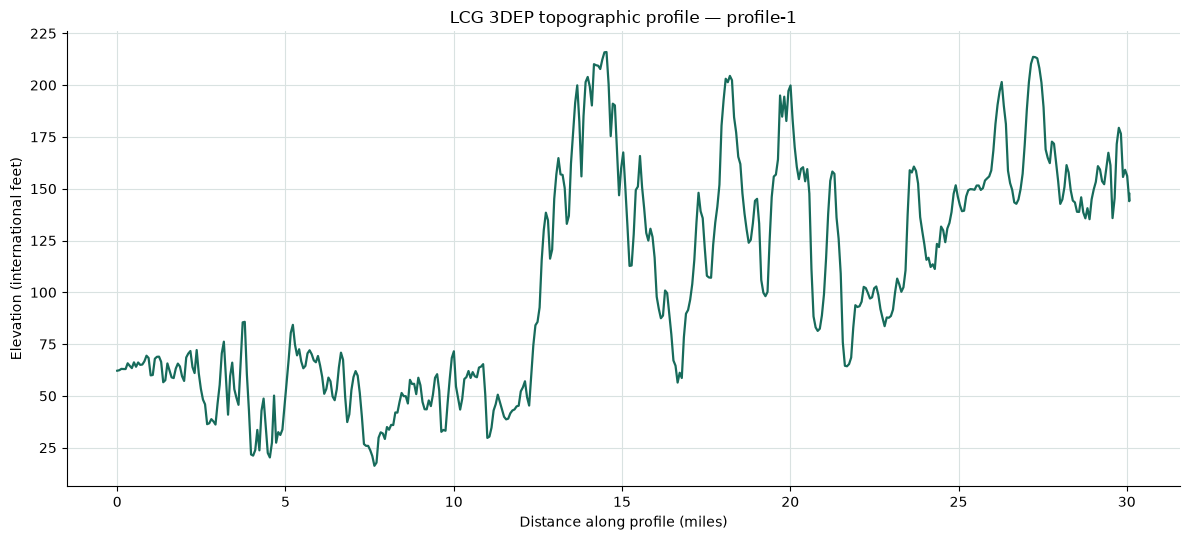

In [25]:
x_column = "distance_miles" if HORIZONTAL_UNITS == "miles" else "distance_km"
x_label = (
    "Distance along profile (miles)"
    if HORIZONTAL_UNITS == "miles"
    else "Distance along profile (km)"
)
y_label = "Elevation (international feet)" if ELEVATION_UNITS == "feet" else "Elevation (meters)"

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(
    profile[x_column],
    profile["elevation"],
    color="#176B5B",
    linewidth=1.6,
)
ax.set_title(f"LCG 3DEP topographic profile — {profile['profile_id'].iloc[0]}")
ax.set_xlabel(x_label)
ax.set_ylabel(y_label)
ax.grid(True, color="#D9E2E1", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

## 11. Export reviewable results

CSV retains the complete ordered table. GeoJSON contains one profile LineString and one Point feature per sample in WGS 84 longitude/latitude order. Metadata is saved separately so downstream users can identify the elevation source and vertical reference.

In [26]:
def json_scalar(value: Any) -> Any:
    if pd.isna(value):
        return None
    if hasattr(value, "item"):
        return value.item()
    return value


OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
csv_path = OUTPUT_DIRECTORY / "topographic_profile_results.csv"
geojson_path = OUTPUT_DIRECTORY / "topographic_profile.geojson"
plot_path = OUTPUT_DIRECTORY / "topographic_profile.png"
metadata_path = OUTPUT_DIRECTORY / "topographic_profile_metadata.json"

profile.to_csv(csv_path, index=False)
fig.savefig(plot_path, dpi=180, bbox_inches="tight")

line_coordinates = [
    [float(row.longitude), float(row.latitude)]
    for row in profile.itertuples(index=False)
]
profile_metadata = {
    "profile_id": profile["profile_id"].iloc[0],
    "service": service_metadata,
    "geometry": geometry_metrics,
    "geometry_warnings": geometry_warnings,
}
features: list[dict[str, Any]] = [
    {
        "type": "Feature",
        "properties": {
            "feature_type": "profile_line",
            "profile_id": profile["profile_id"].iloc[0],
            **service_metadata,
        },
        "geometry": {"type": "LineString", "coordinates": line_coordinates},
    }
]

for record in profile.to_dict(orient="records"):
    longitude = float(record.pop("longitude"))
    latitude = float(record.pop("latitude"))
    properties = {key: json_scalar(value) for key, value in record.items()}
    properties["feature_type"] = "profile_point"
    features.append(
        {
            "type": "Feature",
            "properties": properties,
            "geometry": {"type": "Point", "coordinates": [longitude, latitude]},
        }
    )

geojson = {"type": "FeatureCollection", "features": features}
with geojson_path.open("w", encoding="utf-8") as stream:
    json.dump(geojson, stream, indent=2, allow_nan=False)
    stream.write("\n")

with metadata_path.open("w", encoding="utf-8") as stream:
    json.dump(profile_metadata, stream, indent=2, allow_nan=False)
    stream.write("\n")

for path in (csv_path, geojson_path, plot_path, metadata_path):
    print(path)

C:\Users\leste\OneDrive - LogicCloud Geo\Documents\Data\Python_Elevation_Service_UsingHyRiver\usgs-elevation-service\output\topographic_profile_results.csv
C:\Users\leste\OneDrive - LogicCloud Geo\Documents\Data\Python_Elevation_Service_UsingHyRiver\usgs-elevation-service\output\topographic_profile.geojson
C:\Users\leste\OneDrive - LogicCloud Geo\Documents\Data\Python_Elevation_Service_UsingHyRiver\usgs-elevation-service\output\topographic_profile.png
C:\Users\leste\OneDrive - LogicCloud Geo\Documents\Data\Python_Elevation_Service_UsingHyRiver\usgs-elevation-service\output\topographic_profile_metadata.json


## 12. Next controlled tests

After the synthetic profile succeeds:

1. Use `XCoord`, `YCoord`, and `ORIG_SEQ` directly from an ArcGIS tab-delimited export.
2. Review the plan-view diagnostic before every live request, especially after editing sequence values.
3. Compare several returned elevations with independent map or desktop-GIS inspection.
4. Keep the proven 250-point batch default; test 500 only as a deliberate live capacity experiment.
5. Decide which diagnostics and plots should become part of the ArcGIS tool and public web interface.